# Lecture 5: Feature Engineering


Feature engineering is one of the most critical steps in the machine learning pipeline. It involves transforming raw data into features that better represent the underlying problem to the predictive models, resulting in improved model accuracy on unseen data.

```{note}
Good features can make the difference between a mediocre model and an excellent one. Domain knowledge is essential for creating meaningful features.
```

## Setup and Data Loading

Let's start by importing the necessary libraries and loading the California Housing dataset, which we'll use throughout this notebook to demonstrate various feature engineering techniques.

In [37]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, KBinsDiscretizer,
    OneHotEncoder, OrdinalEncoder, FunctionTransformer,
    PolynomialFeatures
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import CountVectorizer

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [38]:
# Load California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(f"Dataset shape: {df.shape}")
print(f"\nFeatures: {list(df.columns)}")
df.head()

Dataset shape: (20640, 9)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [39]:
# Display basic statistics
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 1. The Two Scopes of Feature Engineering

Feature engineering can be typically split into two distinct parts:

### 1.1 Preparing Feature Library

This spans all activities from fixing data types, cleaning the data, to creating new features from existing or external sources and documenting features. These activities are usually **observation/row-specific**.

Activities include:
- Fixing data types (dtypes)
- Data cleaning and validation
- Creating new features from existing ones
- Incorporating external data sources
- Feature documentation

```{important}
Domain knowledge is key at this stage. Coming up with predictive features for the given use case is essential. Leveraging domain expertise helps create impactful features.
```

#### Example: Creating Domain-Specific Features

Let's create some domain-specific features for the housing dataset:

In [40]:
# Create a copy for feature engineering
df_engineered = df.copy()

# Create meaningful ratio features
df_engineered['rooms_per_household'] = df_engineered['AveRooms'] / df_engineered['AveOccup']
df_engineered['bedrooms_per_room'] = df_engineered['AveBedrms'] / df_engineered['AveRooms']
df_engineered['population_per_household'] = df_engineered['Population'] / df_engineered['HouseAge']

# Display new features
print("New features created:")
df_engineered[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].head()

New features created:


,rooms_per_household,bedrooms_per_room,population_per_household
0,2.732919,0.146591,7.853659
1,2.956685,0.155797,114.333333
2,2.957661,0.129516,9.538462
3,2.283154,0.184458,10.730769
4,2.879646,0.172096,10.865385


```{note}
Combinations of existing features such as ratios can provide more condensed information for a model. Examples include:
- Horse power per kg for used car prices
- Clicks per second for bot detection
- Rooms per household for housing prices
```

### 1.2 Transforming Features for Modelling

This stage transforms the features to be used by the estimator. Transformations can be **model-specific** and can use information from multiple rows (e.g., mean imputation or quantile bins).

```{warning}
We must be careful about potential data leakage between train and validation sets when using information from multiple rows.
```

Key considerations:
- Can the estimator handle missing values?
- Does the model require one-hot encoding for categorical variables?
- Do we need to parameterize the model (e.g., interaction terms)?
- Does the model benefit from feature scaling?

![fe_workflow](figures/FE_workflow.png)


### 1.3 Feature Libraries and Documentation

```{tip}
It's good practice to organize all your feature definitions in a central place. This allows you to:
- Share feature definitions between modeling and production
- Serve as a central store and documentation for features
- Enable reuse across various use cases
```

For production systems, consider using feature store libraries like:
- **Feast** (Feature Store)
- **Tecton**
- **Featureform**

These tools help maintain consistency between training and serving environments.

## 2. Data Leakage

Data leakage refers to a scenario where information from outside the training dataset is inappropriately used to create a model. This can lead to unrealistically good performance on training data but poor generalization to new, unseen data.

```{danger}
Data leakage is one of the most common mistakes in machine learning and can completely invalidate your model's performance estimates.
```

### 2.1 Types of Data Leakage

#### 1. Leaking Information from the Future
Using information that would not actually be available at prediction time.

**Example:** Training a stock price prediction model but including future stock prices.

#### 2. Target Leakage
Including features that directly or indirectly leak information about the target variable.

**Example:** Predicting customer conversion on a website but including clicks on the "Buy" button as a feature.

#### 3. Data Preprocessing Leakage
Inappropriate preprocessing steps that introduce information from the test set into the training set.

**Example:** Imputing missing values using the mean of the entire dataset (including test data) rather than just the training data.

### 2.2 Avoiding Data Leakage

```{important}
Feature transformations should be treated as the first stage of your model pipeline. Always fit transformers on training data only and then apply them to validation/test data.
```

In [41]:
# Proper train-test split
X = df_engineered.drop('MedHouseVal', axis=1)
y = df_engineered['MedHouseVal']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 16512
Test set size: 4128


```{tip}
**Best Practice:** Fix your train and validation set definition for any model pipeline you're training. Use hash-based splitting on primary keys so the same entity (contract/person/house) always ends up in the same bucket.
```

In [42]:
# Example: Wrong way (data leakage)
# DON'T DO THIS!
scaler_wrong = StandardScaler()
X_scaled_wrong = scaler_wrong.fit_transform(X)  # Fit on entire dataset
X_train_wrong = X_scaled_wrong[:len(X_train)]
X_test_wrong = X_scaled_wrong[len(X_train):]

print("❌ Wrong: Fitting on entire dataset causes leakage!\n")

# Correct way (no leakage)
scaler_correct = StandardScaler()
X_train_correct = scaler_correct.fit_transform(X_train)  # Fit only on training data
X_test_correct = scaler_correct.transform(X_test)  # Only transform test data

print("✅ Correct: Fit on training data, transform test data")

❌ Wrong: Fitting on entire dataset causes leakage!

✅ Correct: Fit on training data, transform test data


## 3. Numerical Features

There are various ways to transform numerical features for modeling. Key questions to consider:

- Should the feature be discretized or kept continuous?
- Do we need to scale the feature?
- Do we need non-linear transformations to capture non-linearities?

```{note}
Some answers heavily depend on the underlying estimator. For instance, parametric models may need non-linear transformations, while tree-based approaches (Random Forest, GBMs) find adequate splits automatically.
```

### 3.1 Binning of Numerical Features

Discretizing numerical features allows for relatively flexible marginal effects in parametric models, as we estimate a coefficient for each bin.

**Use cases:**
- Allow flexible effects in parametric models
- Implement business rules (e.g., age groups)
- Reduce sensitivity to outliers

#### Quantile Binning

Quantile binning creates bins with approximately equal numbers of observations.

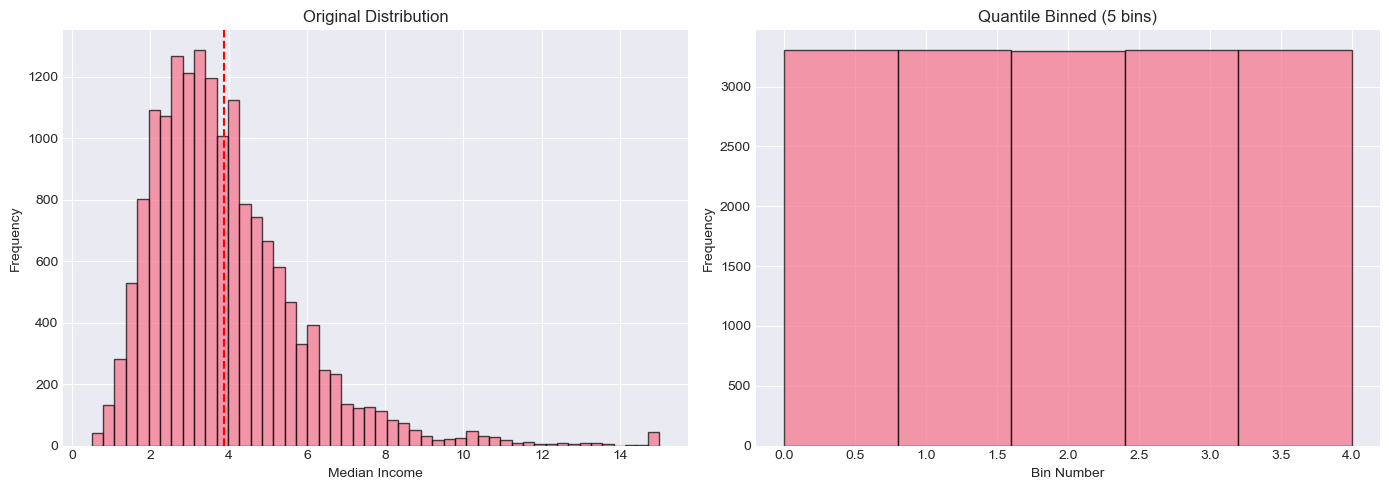

Bin edges: [ 0.4999   2.35652  3.14596  3.9792   5.13116 15.0001 ]


In [43]:
# Quantile binning example
discretizer_quantile = KBinsDiscretizer(
    n_bins=5,
    encode='ordinal',
    strategy='quantile'
)

# Apply to MedInc (Median Income)
income_binned = discretizer_quantile.fit_transform(X_train[['MedInc']])

# Visualize the binning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(X_train['MedInc'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Median Income')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Original Distribution')
axes[0].axvline(X_train['MedInc'].mean(), color='red', linestyle='--', label='Mean')

axes[1].hist(income_binned, bins=5, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Bin Number')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Quantile Binned (5 bins)')

plt.tight_layout()
plt.show()

print(f"Bin edges: {discretizer_quantile.bin_edges_[0]}")

#### Uniform Binning

Uniform binning creates bins of equal width across the feature range.

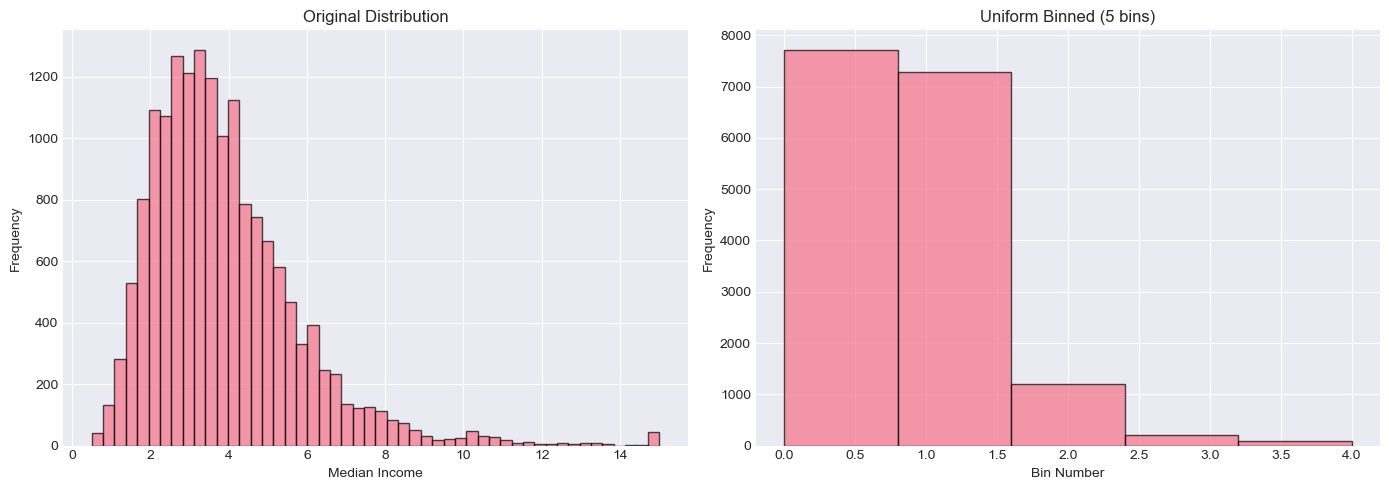

Bin edges: [ 0.4999   3.39994  6.29998  9.20002 12.10006 15.0001 ]


In [44]:
# Uniform binning example
discretizer_uniform = KBinsDiscretizer(
    n_bins=5,
    encode='ordinal',
    strategy='uniform'
)

income_binned_uniform = discretizer_uniform.fit_transform(X_train[['MedInc']])

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(X_train['MedInc'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Median Income')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Original Distribution')

axes[1].hist(income_binned_uniform, bins=5, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Bin Number')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Uniform Binned (5 bins)')

plt.tight_layout()
plt.show()

print(f"Bin edges: {discretizer_uniform.bin_edges_[0]}")

#### Custom Binning

Sometimes business context requires specific discrete cuts.

```{note}
For custom binning, you can write your own transformer or use the flexibility of `FunctionTransformer`.
```

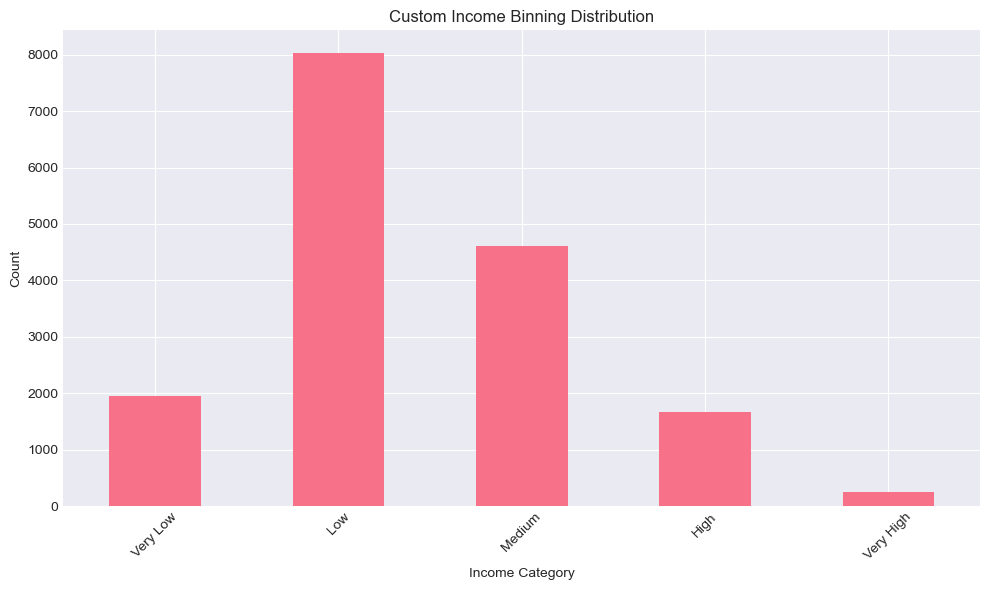

In [45]:
# Custom binning using pd.cut
def custom_income_binning(X):
    """Custom binning for median income."""
    X_copy = X.copy()
    # Define custom bins based on domain knowledge
    bins = [0, 2, 4, 6, 10, np.inf]
    labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
    
    X_copy['MedInc_binned'] = pd.cut(
        X_copy['MedInc'],
        bins=bins,
        labels=labels
    )
    return X_copy

# Apply custom binning
X_train_custom = custom_income_binning(X_train)

# Visualize distribution
plt.figure(figsize=(10, 6))
X_train_custom['MedInc_binned'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Income Category')
plt.ylabel('Count')
plt.title('Custom Income Binning Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.2 Scaling of Numerical Features

Standardization of numerical variables is often good practice for various machine learning algorithms.

```{important}
Many elements used in the objective function of a learning algorithm (such as the RBF kernel of SVMs or the L1/L2 regularizers of linear models) assume that all features are centered around zero or have variance in the same order.
```

If a feature has variance that is orders of magnitude larger than others, it might dominate the objective function and prevent the estimator from learning from other features correctly.

#### Standardization (Z-score normalization)

Transforms features to have mean=0 and standard deviation=1:

$$z = \frac{x - \mu}{\sigma}$$

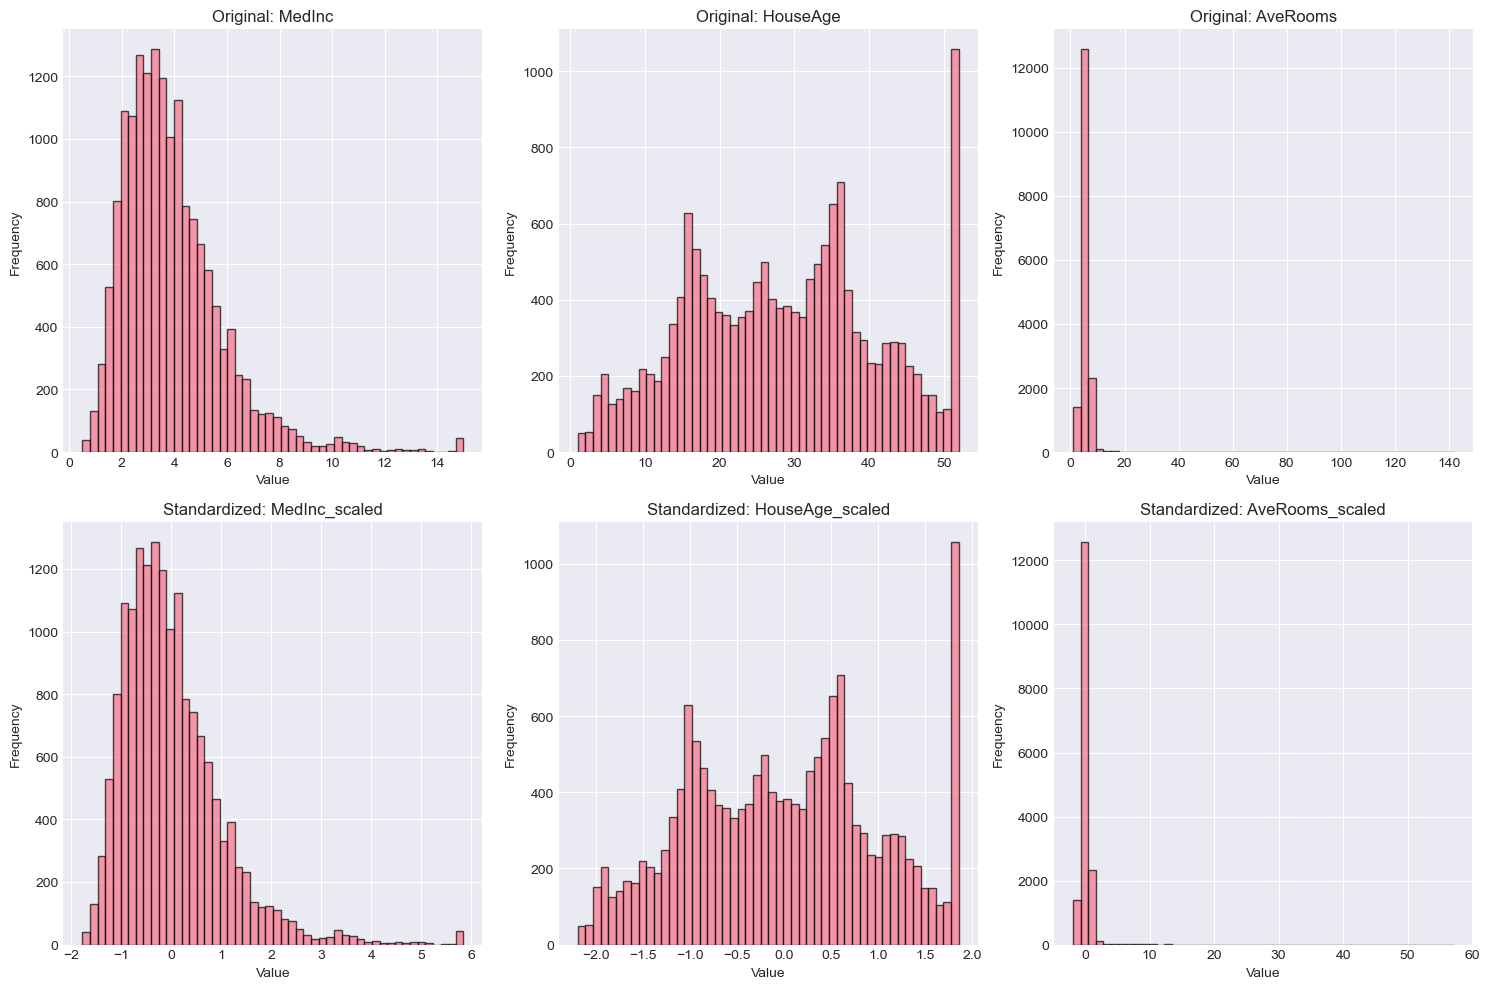

Original statistics:
        MedInc   HouseAge  AveRooms
mean  3.880754  28.608285  5.435235
std   1.904294  12.602499  2.387375

Scaled statistics:
      MedInc_scaled  HouseAge_scaled  AveRooms_scaled
mean  -6.519333e-17    -9.251859e-18    -1.981081e-16
std    1.000030e+00     1.000030e+00     1.000030e+00


In [46]:
# Standardization example
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[['MedInc', 'HouseAge', 'AveRooms']])
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=['MedInc_scaled', 'HouseAge_scaled', 'AveRooms_scaled']
)

# Compare before and after
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

features = ['MedInc', 'HouseAge', 'AveRooms']
scaled_features = ['MedInc_scaled', 'HouseAge_scaled', 'AveRooms_scaled']

for i, (feat, scaled_feat) in enumerate(zip(features, scaled_features)):
    # Original
    axes[0, i].hist(X_train[feat], bins=50, edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'Original: {feat}')
    axes[0, i].set_xlabel('Value')
    axes[0, i].set_ylabel('Frequency')
    
    # Scaled
    axes[1, i].hist(X_train_scaled_df[scaled_feat], bins=50, edgecolor='black', alpha=0.7)
    axes[1, i].set_title(f'Standardized: {scaled_feat}')
    axes[1, i].set_xlabel('Value')
    axes[1, i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Original statistics:")
print(X_train[features].describe().loc[['mean', 'std']])
print("\nScaled statistics:")
print(X_train_scaled_df.describe().loc[['mean', 'std']])

#### Min-Max Scaling

Scales features to a fixed range, typically [0, 1]:

$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

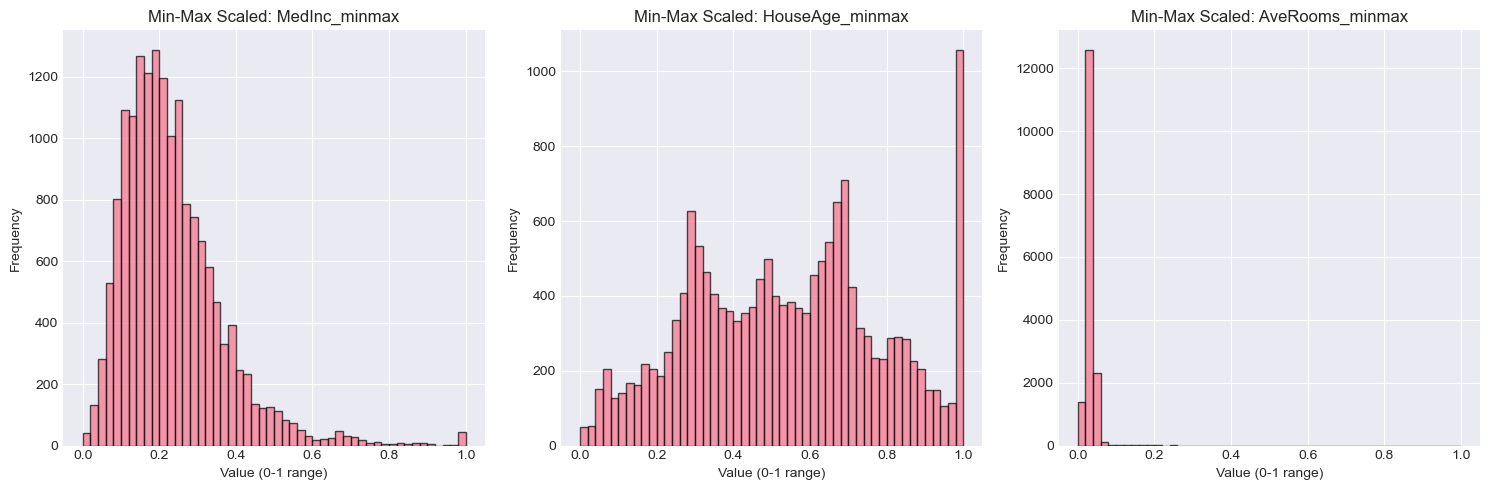

Min-Max scaled statistics:
     MedInc_minmax  HouseAge_minmax  AveRooms_minmax
min            0.0              0.0              0.0
max            1.0              1.0              1.0


In [47]:
# Min-Max scaling example
minmax_scaler = MinMaxScaler()
X_train_minmax = minmax_scaler.fit_transform(X_train[['MedInc', 'HouseAge', 'AveRooms']])
X_train_minmax_df = pd.DataFrame(
    X_train_minmax,
    columns=['MedInc_minmax', 'HouseAge_minmax', 'AveRooms_minmax']
)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feat in enumerate(['MedInc_minmax', 'HouseAge_minmax', 'AveRooms_minmax']):
    axes[i].hist(X_train_minmax_df[feat], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Min-Max Scaled: {feat}')
    axes[i].set_xlabel('Value (0-1 range)')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Min-Max scaled statistics:")
print(X_train_minmax_df.describe().loc[['min', 'max']])

### 3.3 Non-linear Transformations

For (generalized) linear models, we often aim to increase flexibility by including non-linear transformations of numeric features.

```{note}
Tree-based models (Random Forest, Gradient Boosting) can capture non-linearities naturally through splits, so these transformations are typically unnecessary for those models.
```

#### Log Transformation

Log transformation is common to:
- Reduce the effect of outliers
- Reduce skewness to arrive at a more symmetric distribution
- Transform roughly log-normal distributions to normal

```{warning}
**Jensen's Inequality:** When log-transforming the dependent variable, remember that $\phi(E[x]) \leq E[\phi(x)]$ for convex transformations. Use appropriate bias corrections when transforming back, or consider using link functions instead.
```

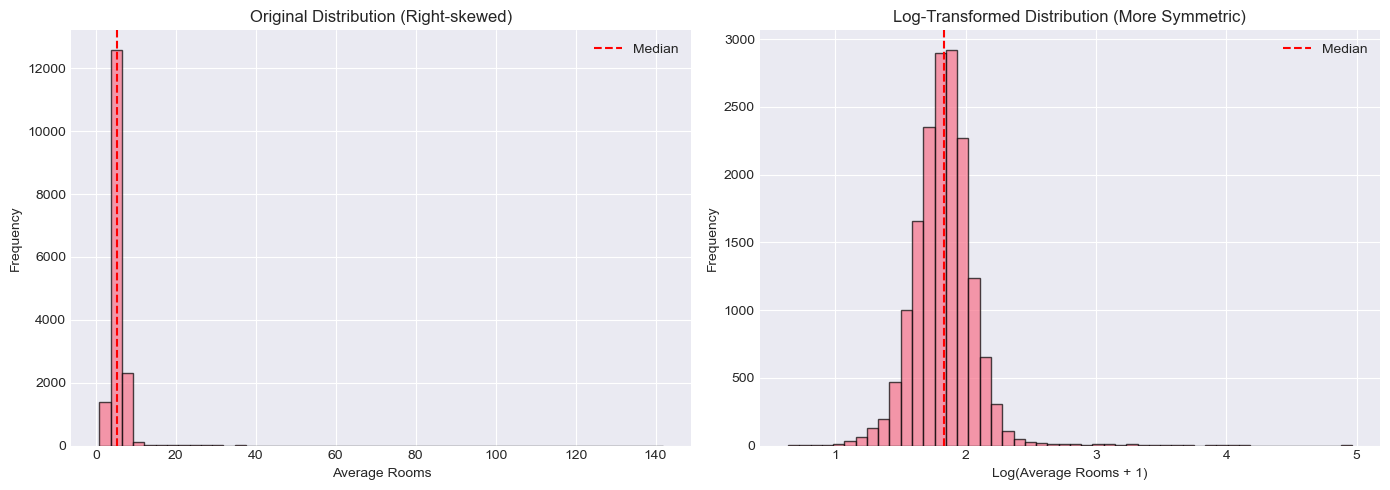

Original skewness: 18.607
Log-transformed skewness: 1.338


In [48]:
# Log transformation example
log_transformer = FunctionTransformer(np.log1p, validate=True)  # log1p handles zeros

# Apply to AveRooms (which is skewed)
rooms_log = log_transformer.fit_transform(X_train[['AveRooms']])

# Visualize the effect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(X_train['AveRooms'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Average Rooms')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Original Distribution (Right-skewed)')
axes[0].axvline(X_train['AveRooms'].median(), color='red', linestyle='--', label='Median')
axes[0].legend()

axes[1].hist(rooms_log, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Log(Average Rooms + 1)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Log-Transformed Distribution (More Symmetric)')
axes[1].axvline(np.median(rooms_log), color='red', linestyle='--', label='Median')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Original skewness: {X_train['AveRooms'].skew():.3f}")
print(f"Log-transformed skewness: {pd.Series(rooms_log.flatten()).skew():.3f}")

#### Polynomial Features

Polynomial features allow linear models to capture non-linear relationships by creating polynomial and interaction terms.

In [49]:
# Polynomial features example
poly = PolynomialFeatures(degree=2, include_bias=False)

# Apply to a subset of features
X_subset = X_train[['MedInc', 'HouseAge']].head(100)
X_poly = poly.fit_transform(X_subset)

# Get feature names
feature_names = poly.get_feature_names_out(['MedInc', 'HouseAge'])

print(f"Original features: {X_subset.shape[1]}")
print(f"Polynomial features (degree 2): {X_poly.shape[1]}")
print(f"\nFeature names: {feature_names}")

# Show a sample
X_poly_df = pd.DataFrame(X_poly, columns=feature_names)
print("\nSample of polynomial features:")
X_poly_df.head()

Original features: 2
Polynomial features (degree 2): 5

Feature names: ['MedInc' 'HouseAge' 'MedInc^2' 'MedInc HouseAge' 'HouseAge^2']

Sample of polynomial features:


,MedInc,HouseAge,MedInc^2,MedInc HouseAge,HouseAge^2
0,3.2596,33.0,10.624992,107.5668,1089.0
1,3.8125,49.0,14.535156,186.8125,2401.0
2,4.1563,4.0,17.274830,16.6252,16.0
3,1.9425,36.0,3.773306,69.9300,1296.0
4,3.5542,43.0,12.632338,152.8306,1849.0


```{note}
Polynomial features can quickly increase dimensionality. With $n$ features and degree $d$, the number of features becomes $\binom{n+d}{d}$. Use with caution for high-dimensional data.


#### Splines

Splines can be interpreted as a mix of binning a numerical variable, but instead of indicators, we use polynomials, which adds flexibility and smoothness.

**Key concepts:**
- **B-splines (basis splines):** Collection of piecewise polynomial functions
- **Knots:** Positions where pieces are glued together
- Better extrapolation than high-degree polynomials
- Avoid high oscillatory behavior

/Users/christianrorig/opt/miniconda3/envs/fun_ds/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SplineTransformer was fitted with feature names
  warnings.warn(
/Users/christianrorig/opt/miniconda3/envs/fun_ds/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


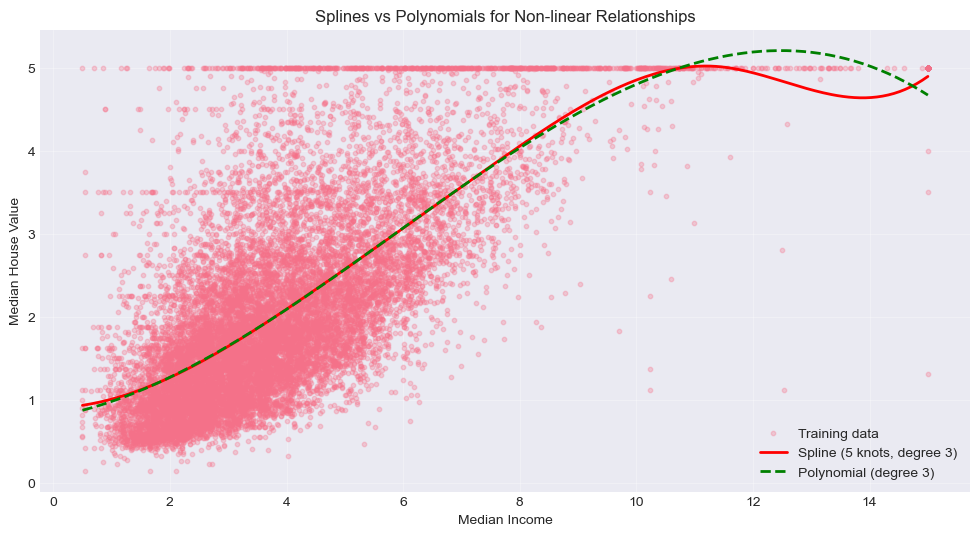

In [50]:
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import LinearRegression

# Create spline features
spline = SplineTransformer(n_knots=5, degree=3, include_bias=False)

# Use MedInc to predict MedHouseVal
X_spline = spline.fit_transform(X_train[['MedInc']])

# Fit a simple linear model on spline features
model_spline = LinearRegression()
model_spline.fit(X_spline, y_train)

# Compare with polynomial
poly_3 = PolynomialFeatures(degree=3, include_bias=False)
X_poly_3 = poly_3.fit_transform(X_train[['MedInc']])
model_poly = LinearRegression()
model_poly.fit(X_poly_3, y_train)

# Visualize
X_plot = np.linspace(X_train['MedInc'].min(), X_train['MedInc'].max(), 300).reshape(-1, 1)
X_plot_spline = spline.transform(X_plot)
X_plot_poly = poly_3.transform(X_plot)

y_pred_spline = model_spline.predict(X_plot_spline)
y_pred_poly = model_poly.predict(X_plot_poly)

plt.figure(figsize=(12, 6))
plt.scatter(X_train['MedInc'], y_train, alpha=0.3, s=10, label='Training data')
plt.plot(X_plot, y_pred_spline, 'r-', linewidth=2, label='Spline (5 knots, degree 3)')
plt.plot(X_plot, y_pred_poly, 'g--', linewidth=2, label='Polynomial (degree 3)')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Splines vs Polynomials for Non-linear Relationships')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Categorical Features

Categorical features represent categories or labels with these characteristics:

- **Distinct values:** Finite number of categories (e.g., weekdays, colors)
- **No inherent order:** Typically no natural ordering, though context may suggest one
- **Encoding required:** Most estimators require numerical encoding

{note}
A categorical feature doesn't have to be a string variable. It can be numeric if we don't want to imply ranking. For example, year could be treated as categorical to capture year fixed effects rather than a linear trend.


### Creating a Categorical Feature

Let's create a categorical feature from our housing data for demonstration:

In [51]:
# Create categorical features for demonstration
X_train_cat = X_train.copy()
X_test_cat = X_test.copy()

# Create location category based on lat/long
def categorize_location(df):
    df = df.copy()
    # Simple categorization based on latitude
    conditions = [
        df['Latitude'] >= 38,
        (df['Latitude'] >= 36) & (df['Latitude'] < 38),
        (df['Latitude'] >= 34) & (df['Latitude'] < 36),
        df['Latitude'] < 34
    ]
    choices = ['North', 'North-Central', 'South-Central', 'South']
    df['Region'] = np.select(conditions, choices, default='Unknown')
    return df

X_train_cat = categorize_location(X_train_cat)
X_test_cat = categorize_location(X_test_cat)

print("Region distribution in training set:")
print(X_train_cat['Region'].value_counts())
print(f"\nNumber of unique regions: {X_train_cat['Region'].nunique()}")

Region distribution in training set:
Region
South            4911
North-Central    4625
South-Central    4505
North            2471
Name: count, dtype: int64

Number of unique regions: 4


### 4.1 Ordinal Encoding

Sometimes we want to provide information about the contextual order of a categorical variable, e.g., to include a monotonicity constraint.

```{tip}
Use ordinal encoding when:
- There's a natural ordering to categories (e.g., low, medium, high)
- You want to enforce monotonicity constraints
- Working with tree-based models that can utilize ordering
```

In [52]:
# Ordinal encoding example
# Define the order for regions (South to North)
ordinal_encoder = OrdinalEncoder(
    categories=[['South', 'South-Central', 'North-Central', 'North']],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

region_ordinal = ordinal_encoder.fit_transform(X_train_cat[['Region']])

# Display mapping
mapping_df = pd.DataFrame({
    'Region': ordinal_encoder.categories_[0],
    'Encoded Value': range(len(ordinal_encoder.categories_[0]))
})
print("Ordinal Encoding Mapping:")
print(mapping_df)

Ordinal Encoding Mapping:
          Region  Encoded Value
0          South              0
1  South-Central              1
2  North-Central              2
3          North              3


### 4.2 One-Hot Encoding

In the absence of any monotonicity constraint, we usually dummy encode the categories (one-hot encoding). This creates binary columns for each category.

```{important}
One-hot encoding can lead to high dimensionality quickly. For variables with many categories (e.g., 200+ categories), consider target encoding instead.
```

In [53]:
# One-hot encoding example
onehot_encoder = OneHotEncoder(sparse_output=False, drop='first')  # Drop first to avoid collinearity

region_onehot = onehot_encoder.fit_transform(X_train_cat[['Region']])

# Get feature names
onehot_feature_names = onehot_encoder.get_feature_names_out(['Region'])
region_onehot_df = pd.DataFrame(region_onehot, columns=onehot_feature_names)

print(f"Original feature: 1 column")
print(f"One-hot encoded: {region_onehot_df.shape[1]} columns")
print("\nOne-hot encoded features:")
print(region_onehot_df.head(10))

Original feature: 1 column
One-hot encoded: 3 columns

One-hot encoded features:
   Region_North-Central  Region_South  Region_South-Central
0                   0.0           1.0                   0.0
1                   0.0           1.0                   0.0
2                   0.0           0.0                   1.0
3                   0.0           1.0                   0.0
4                   1.0           0.0                   0.0
5                   1.0           0.0                   0.0
6                   0.0           0.0                   1.0
7                   1.0           0.0                   0.0
8                   0.0           0.0                   1.0
9                   0.0           0.0                   1.0


### 4.3 Handling Infrequent or Unseen Categories

Often we refrain from estimating individual effects for rare categories as we only observed them a few times and the estimate would have high uncertainty.

```{note}
Think about using car brand as a feature for used car pricing. You'll have many data points for well-known brands but very few for unknown brands. Instead of potentially overfitting, bundle them into a residual category.
```

In [54]:
# Create a categorical with some rare categories
np.random.seed(42)
rare_categories = np.random.choice(
    ['Common_A', 'Common_B', 'Common_C', 'Rare_D', 'Rare_E'],
    size=len(X_train_cat),
    p=[0.4, 0.35, 0.2, 0.03, 0.02]
)
X_train_cat['Category'] = rare_categories

print("Category distribution:")
print(X_train_cat['Category'].value_counts())
print(f"\nTotal categories: {X_train_cat['Category'].nunique()}")

Category distribution:
Category
Common_A    6670
Common_B    5741
Common_C    3300
Rare_D       482
Rare_E       319
Name: count, dtype: int64

Total categories: 5


In [55]:
# Handle infrequent categories
onehot_infrequent = OneHotEncoder(
    min_frequency=500,  # Categories with fewer than 500 observations -> infrequent
    sparse_output=False,
    handle_unknown='infrequent_if_exist'
)

category_encoded = onehot_infrequent.fit_transform(X_train_cat[['Category']])
feature_names = onehot_infrequent.get_feature_names_out(['Category'])

print(f"\nEncoded features: {feature_names}")
print(f"Note: 'infrequent_sklearn' groups rare categories together")


Encoded features: ['Category_Common_A' 'Category_Common_B' 'Category_Common_C'
 'Category_infrequent_sklearn']
Note: 'infrequent_sklearn' groups rare categories together


### Handling Unknown Categories at Inference

We must decide what to do with unknown categories at inference time:

- **`error`:** Throw an error
- **`ignore`:** Add a column of zeros (predictions fall back to intercept)
- **`infrequent_if_exist`:** Treat as infrequent category

```{tip}
For production models, you may want even more control over unseen values by subclassing the respective transformers.
```

### 4.4 Gradient Boosting Libraries and Categoricals

```{note}
Modern gradient boosting libraries offer native support for categorical variables:
```
- LightGBM: Can be trained with categorical variables as integers with a notification of which columns are categorical
- XGBoost: Offers experimental support for categoricals starting from version 1.5
- CatBoost: Built specifically to handle categorical features natively


The actual splits differ when providing the categorical as one-hot encoded vs. integer encoded:
- **One-hot:** Binary "Yes"/"No" splits for each category
- **Integer encoded:** Groups of categories, which may need more splits to isolate a single category

## 5. Missing Values

A key factor in the effect of missing values is whether data is missing "at random" or systematically.

```{important}
When data is missing for a reason (as is usually the case in the real world), the fact that it was missing is important information that we should not throw away.
```

### 5.1 Recommended Strategy for Handling Missings

Our preferred recipe:

**For numerical variables:**
1. Impute with a sensible value (e.g., mean or median)
2. Add a binary indicator that flags whether the variable was imputed

**For categorical variables:**
- Create a new level called "missing"

### Research on Imputation Strategies

{note}
Bertsimas et al. (2024) study the performance of various 'impute-then-regress' pipelines:

- Mean imputation is asymptotically optimal
- Mode imputation is sub-optimal
- Missing categoricals should be encoded outside of the support as 'missing' 


In [56]:
# Introduce missing values artificially for demonstration
X_train_missing = X_train.copy()
np.random.seed(42)

# Randomly set 10% of AveRooms to NaN
missing_mask = np.random.random(len(X_train_missing)) < 0.1
X_train_missing.loc[missing_mask, 'AveRooms'] = np.nan

print(f"Missing values in AveRooms: {X_train_missing['AveRooms'].isna().sum()}")
print(f"Percentage missing: {X_train_missing['AveRooms'].isna().mean()*100:.2f}%")

Missing values in AveRooms: 1699
Percentage missing: 10.29%


### 5.2 Simple Imputation Strategies

In [57]:
# Mean imputation
imputer_mean = SimpleImputer(strategy='mean')
rooms_mean_imputed = imputer_mean.fit_transform(X_train_missing[['AveRooms']])

# Median imputation
imputer_median = SimpleImputer(strategy='median')
rooms_median_imputed = imputer_median.fit_transform(X_train_missing[['AveRooms']])

# Constant imputation
imputer_constant = SimpleImputer(strategy='constant', fill_value=0)
rooms_constant_imputed = imputer_constant.fit_transform(X_train_missing[['AveRooms']])

print(f"Original mean: {X_train['AveRooms'].mean():.3f}")
print(f"Mean imputation value: {imputer_mean.statistics_[0]:.3f}")
print(f"Median imputation value: {imputer_median.statistics_[0]:.3f}")

Original mean: 5.435
Mean imputation value: 5.432
Median imputation value: 5.236


### 5.3 Adding Missing Indicators

```{tip}
Always add a binary indicator for imputed values to preserve the information that data was missing.
```

In [58]:
from sklearn.impute import MissingIndicator

# Create missing indicator
missing_indicator = MissingIndicator()
rooms_missing_indicator = missing_indicator.fit_transform(X_train_missing[['AveRooms']])

# Combine imputed values with indicator
X_train_imputed = pd.DataFrame({
    'AveRooms_imputed': rooms_mean_imputed.flatten(),
    'AveRooms_was_missing': rooms_missing_indicator.flatten()
})

print("Imputed data with missing indicator:")
print(X_train_imputed.head(20))
print(f"\nNumber of missing indicators = 1: {X_train_imputed['AveRooms_was_missing'].sum()}")

Imputed data with missing indicator:
    AveRooms_imputed  AveRooms_was_missing
0           5.017657                 False
1           4.473545                 False
2           5.645833                 False
3           4.002817                 False
4           6.268421                 False
5           6.282147                 False
6           5.431594                  True
7           6.052758                 False
8           3.620579                 False
9           6.730284                 False
10          5.431594                  True
11          3.241739                 False
12          6.490260                 False
13          3.012658                 False
14          4.722034                 False
15          5.054475                 False
16          5.355353                 False
17          5.900560                 False
18          4.994361                 False
19          3.057762                 False

Number of missing indicators = 1: 1699


### 5.4 Handling Missing Categorical Values

In [59]:
# Introduce missing values in categorical
X_train_cat_missing = X_train_cat.copy()
missing_cat_mask = np.random.random(len(X_train_cat_missing)) < 0.05
X_train_cat_missing.loc[missing_cat_mask, 'Region'] = np.nan

print(f"Missing regions: {X_train_cat_missing['Region'].isna().sum()}")

# Impute with constant value 'Missing'
imputer_cat = SimpleImputer(strategy='constant', fill_value='Missing')
region_imputed = imputer_cat.fit_transform(X_train_cat_missing[['Region']])

print("\nRegion distribution after imputation:")
print(pd.Series(region_imputed.flatten()).value_counts())

Missing regions: 776

Region distribution after imputation:
South            4665
North-Central    4430
South-Central    4266
North            2375
Missing           776
Name: count, dtype: int64


## 6. Outliers

Outliers can occur in features as well as target variables. Understanding their background is crucial:

{note}
Ask yourself:
- Is it a typo making the observation magnitudes larger than others?
- Is such an outlier possible given the underlying data generating process?

In the first case, you might want to drop or winsorize the data. In the second case, you're interested in capturing such outliers properly.


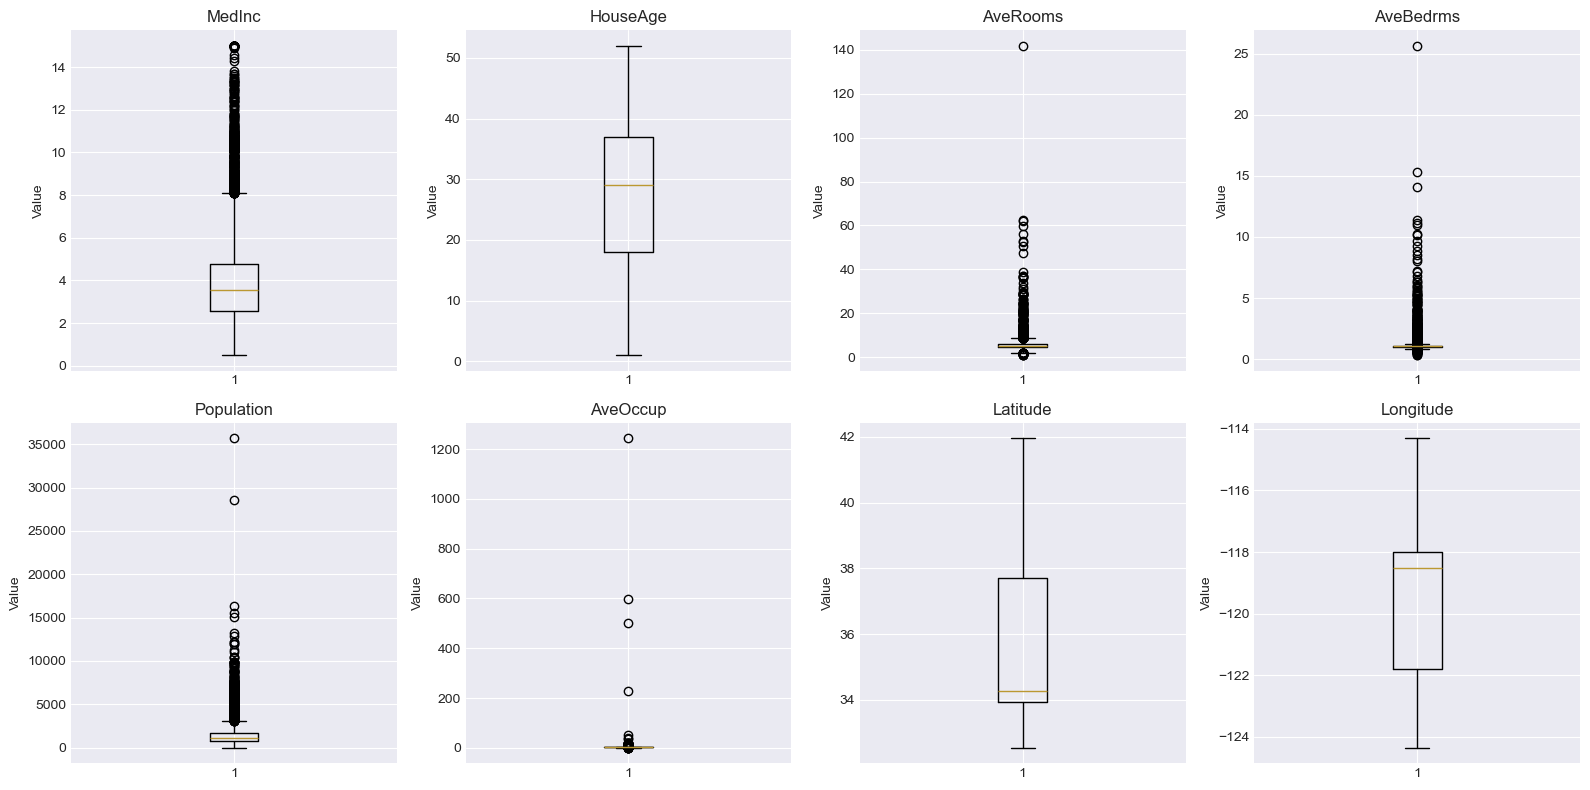


Features with potential outliers:
AveRooms: 410 outliers (2.48%)
AveBedrms: 1153 outliers (6.98%)
AveOccup: 582 outliers (3.52%)


In [60]:
# Visualize potential outliers
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

numeric_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 
                     'Population', 'AveOccup', 'Latitude', 'Longitude']

for i, col in enumerate(numeric_features):
    axes[i].boxplot(X_train[col], vert=True)
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

# Show statistics for features with potential outliers
print("\nFeatures with potential outliers:")
for col in ['AveRooms', 'AveBedrms', 'AveOccup']:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((X_train[col] < q1 - 1.5*iqr) | (X_train[col] > q3 + 1.5*iqr)).sum()
    print(f"{col}: {outliers} outliers ({outliers/len(X_train)*100:.2f}%)")

### 6.1 Winsorization

Winsorization caps extreme values at specified percentiles.

{note}
Scikit-learn doesn't offer a built-in winsorization transformer, but we can use libraries like feature_engine or write our own custom transformer.


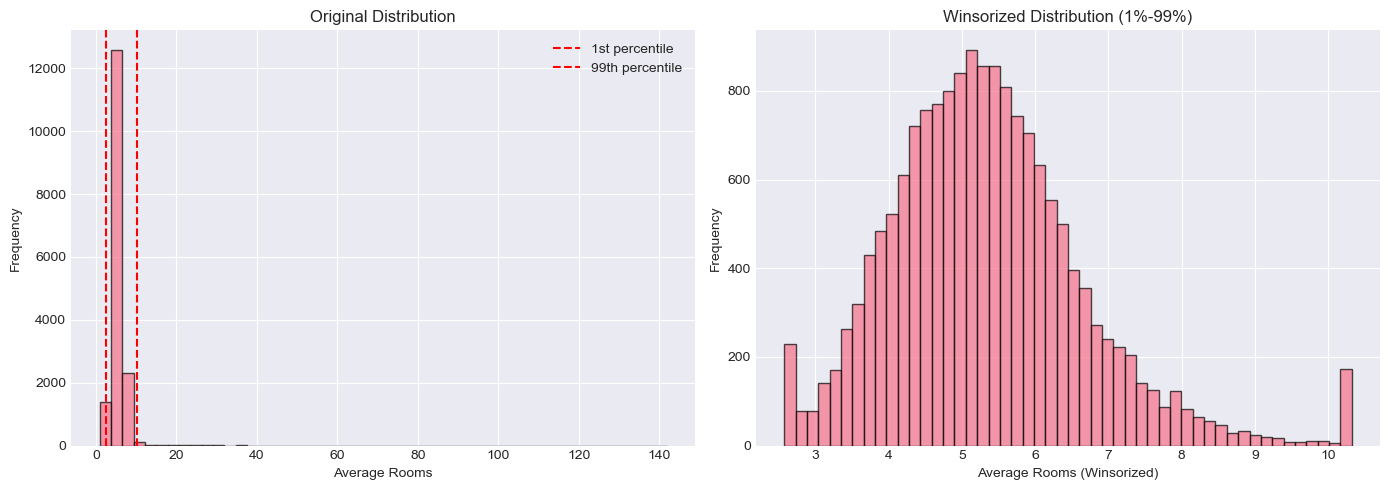

Original range: [0.89, 141.91]
Winsorized range: [2.58, 10.32]


In [61]:
# Custom winsorization function
def winsorize_feature(X, lower_percentile=0.01, upper_percentile=0.99):
    """Winsorize feature by capping at percentiles."""
    X_copy = X.copy()
    lower = np.percentile(X_copy, lower_percentile * 100)
    upper = np.percentile(X_copy, upper_percentile * 100)
    X_copy = np.clip(X_copy, lower, upper)
    return X_copy

# Apply to AveRooms
rooms_original = X_train['AveRooms'].values
rooms_winsorized = winsorize_feature(rooms_original, 0.01, 0.99)

# Visualize effect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(rooms_original, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Average Rooms')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Original Distribution')
axes[0].axvline(np.percentile(rooms_original, 1), color='red', 
                linestyle='--', label='1st percentile')
axes[0].axvline(np.percentile(rooms_original, 99), color='red', 
                linestyle='--', label='99th percentile')
axes[0].legend()

axes[1].hist(rooms_winsorized, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Average Rooms (Winsorized)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Winsorized Distribution (1%-99%)')

plt.tight_layout()
plt.show()

print(f"Original range: [{rooms_original.min():.2f}, {rooms_original.max():.2f}]")
print(f"Winsorized range: [{rooms_winsorized.min():.2f}, {rooms_winsorized.max():.2f}]")

## 7. Dimension Reduction

When dealing with many features, especially highly correlated ones, dimension reduction techniques can help create a more compact representation.

### 7.1 Unsupervised Dimension Reduction - PCA

Principal Component Analysis (PCA) extracts as much variance as possible with as few features as possible.

{important}
PCA is sensitive to feature scaling. Features with high variance will dominate the principal components. Always scale features before applying PCA.
```

Example use case: Used car pricing with many correlated numerical variables (length, height, width, horse power, max speed, etc.). PCA can identify clusters of specific car types.

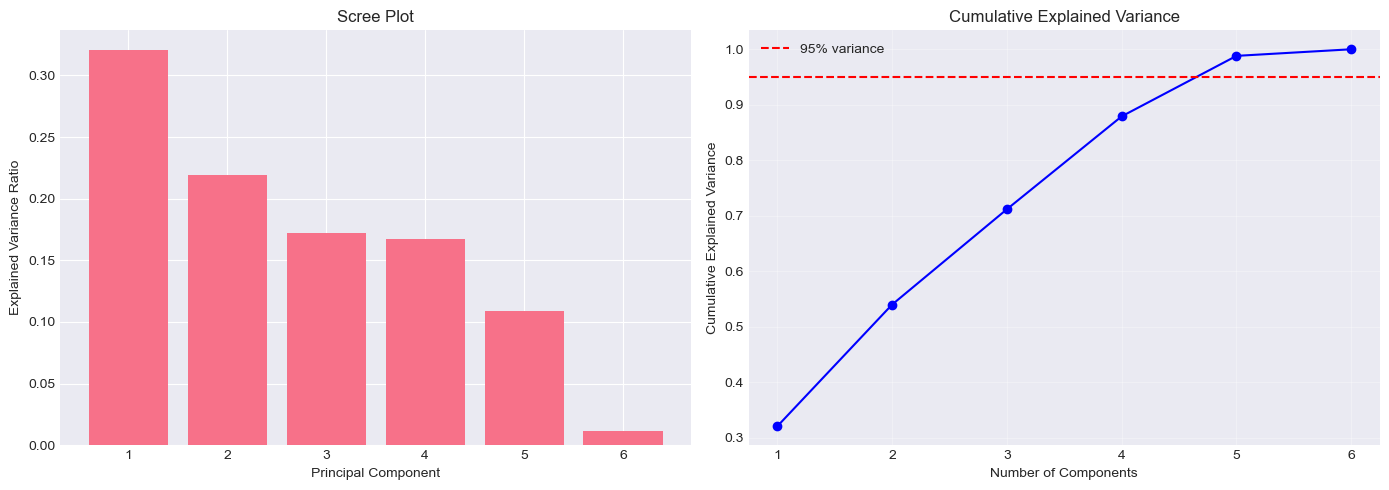

Explained variance ratio per component: 
PC1: 0.3206 (32.06%)
PC2: 0.2193 (21.93%)
PC3: 0.1718 (17.18%)
PC4: 0.1674 (16.74%)
PC5: 0.1090 (10.90%)
PC6: 0.0119 (1.19%)
Components needed for 95% variance: 5


In [62]:
# Apply PCA
# First, scale the features
scaler_pca = StandardScaler()
X_train_scaled_pca = scaler_pca.fit_transform(
    X_train[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']]
)

# Apply PCA
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled_pca)

# Explained variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, len(explained_variance_ratio) + 1))

# Cumulative variance
axes[1].plot(range(1, len(cumulative_variance_ratio) + 1), 
             cumulative_variance_ratio, 'bo-')
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(1, len(cumulative_variance_ratio) + 1))

plt.tight_layout()
plt.show()

print('Explained variance ratio per component: ')
for i, var in enumerate(explained_variance_ratio, 1):
    print(f'PC{i}: {var:.4f} ({var*100:.2f}%)')

# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance_ratio >= 0.95) + 1
print(f'Components needed for 95% variance: {n_components_95}')

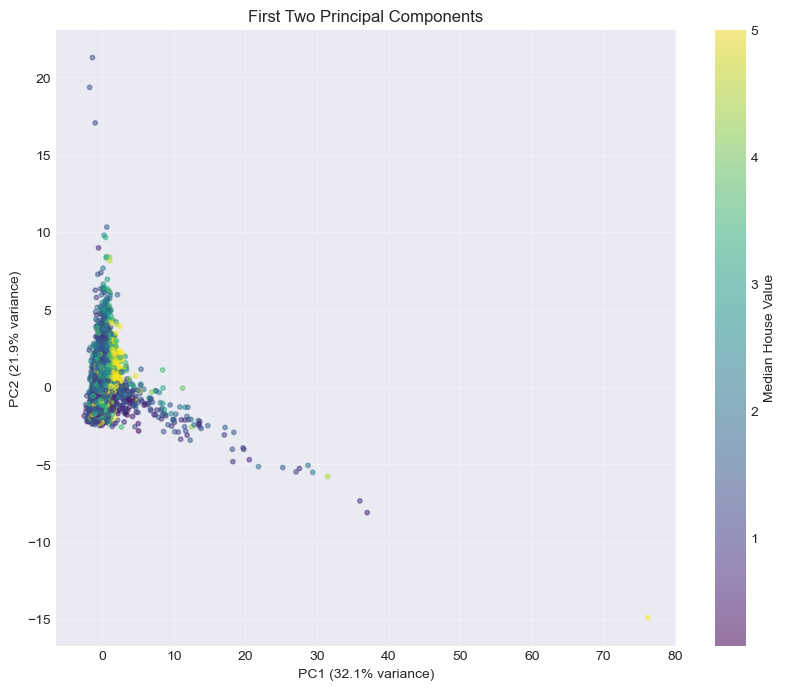

In [63]:
# Visualize first two principal components
pca_2d = PCA(n_components=2)
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled_pca)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_pca_2d[:, 0], X_train_pca_2d[:, 1], 
                     c=y_train, cmap='viridis', alpha=0.5, s=10)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('First Two Principal Components')
plt.colorbar(scatter, label='Median House Value')
plt.grid(True, alpha=0.3)
plt.show()

### 7.2 Supervised Dimension Reduction - Target Encoding

For very high-dimensional categorical variables (e.g., 200 categories), target encoding is a more memory-efficient option than hundreds of dummy columns.

{note}
Target encoding replaces each category with a summary statistic (usually the mean) of the target variable for that category. This creates only one variable instead of many dummy columns.


{warning}
Target encoding can lead to overfitting if not done carefully. Always use cross-validation or smoothing techniques to prevent data leakage.


In [64]:
from sklearn.preprocessing import TargetEncoder

# Use Region for target encoding
target_encoder = TargetEncoder(smooth='auto', target_type='continuous')

# Fit and transform on training data
region_target_encoded = target_encoder.fit_transform(
    X_train_cat[['Region']], 
    y_train
)

# Compare with one-hot encoding
print('Dimensionality comparison: ')
print(f'Original categorical: 1 column')
print(f'One-hot encoded: {X_train_cat['Region'].nunique() - 1} columns (drop first)')
print(f'Target encoded: 1 column')

# Show target encoding values
target_encoding_df = pd.DataFrame({
    'Region': X_train_cat['Region'],
    'Target_Encoded': region_target_encoded.flatten(),
    'Actual_Target': y_train.values
})

print('Mean target value by region: ')
print(target_encoding_df.groupby('Region')['Actual_Target'].mean().sort_values(ascending=False))

print('Sample of target encoded values: ')
print(target_encoding_df.head(10))

Dimensionality comparison: 
Original categorical: 1 column
One-hot encoded: 3 columns (drop first)
Target encoded: 1 column
Mean target value by region: 
Region
North-Central    2.251717
South-Central    2.217538
South            2.124598
North            1.365395
Name: Actual_Target, dtype: float64
Sample of target encoded values: 
              Region  Target_Encoded  Actual_Target
14196          South        2.130365        1.03000
8267           South        2.124290        3.82100
17445  South-Central        2.210296        1.72600
14265          South        2.130365        0.93400
2271   North-Central        2.252494        0.96500
17848  North-Central        2.252494        2.64800
6252   South-Central        2.234673        1.57300
9389   North-Central        2.252494        5.00001
6113   South-Central        2.234673        1.39800
6061   South-Central        2.213097        3.15600


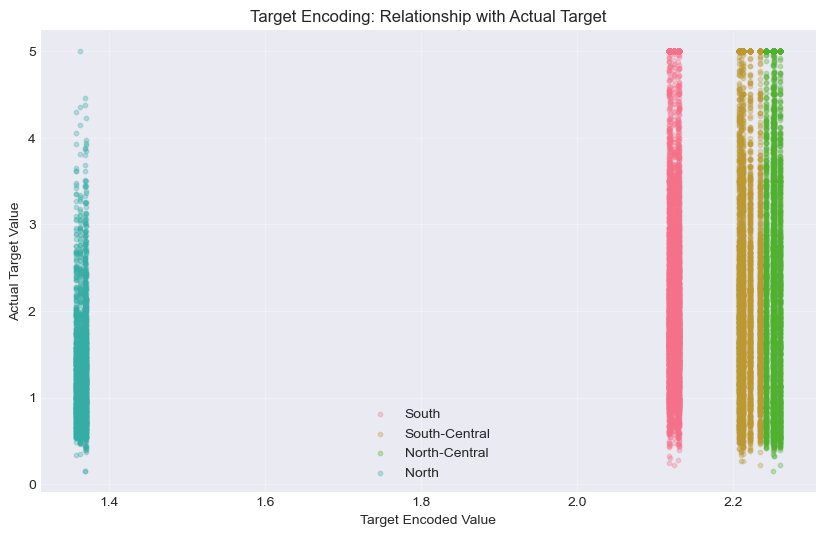

In [65]:
# Visualize target encoding
plt.figure(figsize=(10, 6))
for region in X_train_cat['Region'].unique():
    mask = target_encoding_df['Region'] == region
    plt.scatter(
        target_encoding_df.loc[mask, 'Target_Encoded'],
        target_encoding_df.loc[mask, 'Actual_Target'],
        alpha=0.3,
        label=region,
        s=10
    )

plt.xlabel('Target Encoded Value')
plt.ylabel('Actual Target Value')
plt.title('Target Encoding: Relationship with Actual Target')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Extracting Features from Text

Sometimes we want to leverage information provided as text (e.g., details about an insurance claim). Depending on the extraction method, this can also be seen as dimension reduction.

```{note}
Using the entire string with all its tokens can become very high-dimensional quickly. We want to extract specific commonalities to use in subsequent models.
```

```{tip}
Modern LLMs can also be used as a first stage to provide high-quality signals from text.
```

In [66]:
# Create synthetic text data for demonstration
text_descriptions = [
    'Beautiful modern house near beach with ocean view',
    'Spacious family home with large garden and pool',
    'Cozy apartment in city center near downtown',
    'Luxury villa with ocean view and private beach',
    'Small studio apartment perfect for students',
    'Large house with garden and modern amenities',
    'Beach house with stunning ocean view',
    'Downtown apartment near city center shopping',
]

# CountVectorizer
vectorizer = CountVectorizer(max_features=10, stop_words='english')
text_features = vectorizer.fit_transform(text_descriptions)

# Convert to DataFrame
text_features_df = pd.DataFrame(
    text_features.toarray(),
    columns=vectorizer.get_feature_names_out()
)

print('Original text: ')
for i, text in enumerate(text_descriptions):
    print(f'{i+1}. {text}')

print('Extracted text features (CountVectorizer): ')
print(text_features_df)

print(f'Feature names: {list(vectorizer.get_feature_names_out())}')

Original text: 
1. Beautiful modern house near beach with ocean view
2. Spacious family home with large garden and pool
3. Cozy apartment in city center near downtown
4. Luxury villa with ocean view and private beach
5. Small studio apartment perfect for students
6. Large house with garden and modern amenities
7. Beach house with stunning ocean view
8. Downtown apartment near city center shopping
Extracted text features (CountVectorizer): 
   apartment  beach  center  city  downtown  garden  house  near  ocean  view
0          0      1       0     0         0       0      1     1      1     1
1          0      0       0     0         0       1      0     0      0     0
2          1      0       1     1         1       0      0     1      0     0
3          0      1       0     0         0       0      0     0      1     1
4          1      0       0     0         0       0      0     0      0     0
5          0      0       0     0         0       1      1     0      0     0
6         

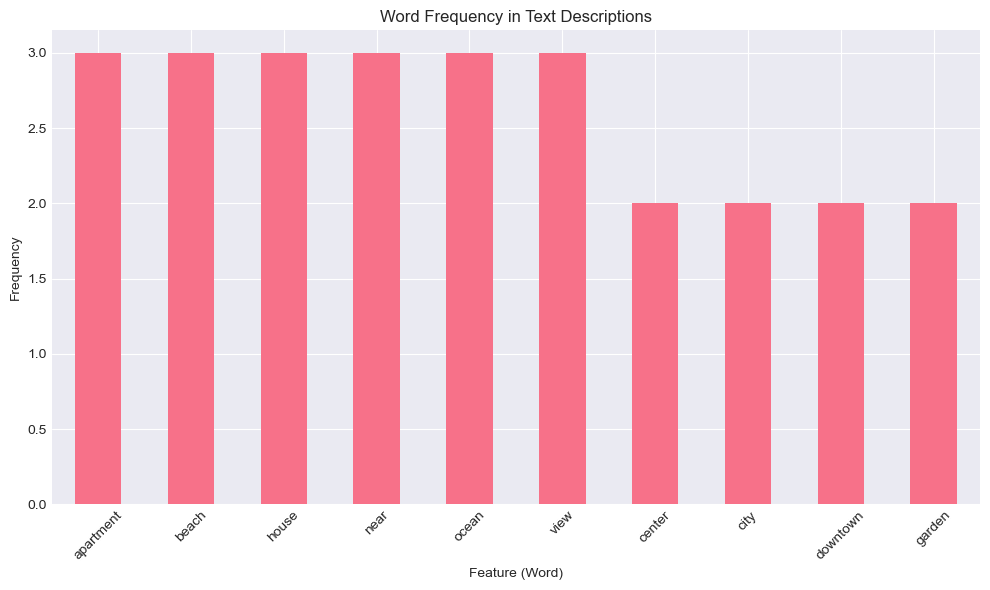

In [67]:
# Visualize feature frequency
feature_sums = text_features_df.sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_sums.plot(kind='bar')
plt.xlabel('Feature (Word)')
plt.ylabel('Frequency')
plt.title('Word Frequency in Text Descriptions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

```{note}
Other text feature extraction methods include:
- **TF-IDF (Term Frequency-Inverse Document Frequency):** Weights words by importance
- **Word embeddings:** Dense vector representations (Word2Vec, GloVe)
- **Sentence embeddings:** Context-aware representations (BERT, Sentence-BERT)
- **LLM-based extraction:** Use large language models to extract structured information
```

## 9. Feature Transformation Pipelines

{important}
Using pipelines allows us to glue specific feature transformations to the respective model, making it easier to port them to production and avoid data leakage.


Scikit-learn's Pipeline class allows us to chain various feature transformations before including an optional estimator.

### 9.1 Simple Pipeline Example

In [68]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Create a simple pipeline
simple_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

# Fit the pipeline
X_train_simple = X_train[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms']]
X_test_simple = X_test[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms']]

simple_pipeline.fit(X_train_simple, y_train)

# Make predictions
y_pred = simple_pipeline.predict(X_test_simple)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Simple Pipeline Results: ')
print(f'MSE: {mse:.4f}')
print(f'R²: {r2:.4f}')
print(f'Pipeline steps: {[step[0] for step in simple_pipeline.steps]}')

Simple Pipeline Results: 
MSE: 0.6435
R²: 0.5089
Pipeline steps: ['imputer', 'scaler', 'model']


### 9.2 ColumnTransformer for Feature-Specific Transformations

In practice, we usually want feature-specific transformations. Scikit-learn's ColumnTransformer enables this.

{tip}
The `ColumnTransformer` is essential for real-world pipelines where different features need different preprocessing steps.


In [69]:
# Prepare data with mixed types
X_train_mixed = X_train_cat[['MedInc', 'HouseAge', 'AveRooms', 'Population', 'Region']].copy()
X_test_mixed = X_test_cat[['MedInc', 'HouseAge', 'AveRooms', 'Population', 'Region']].copy()

# Define numeric and categorical features
numeric_features = ['MedInc', 'HouseAge', 'AveRooms', 'Population']
categorical_features = ['Region']

# Create transformers for different feature types
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Create full pipeline with model
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

# Fit and evaluate
full_pipeline.fit(X_train_mixed, y_train)
y_pred_full = full_pipeline.predict(X_test_mixed)

mse_full = mean_squared_error(y_test, y_pred_full)
r2_full = r2_score(y_test, y_pred_full)

print('Full Pipeline Results: ')
print(f'MSE: {mse_full:.4f}')
print(f'R²: {r2_full:.4f}')
print(f'Pipeline structure: ')
print(full_pipeline)

Full Pipeline Results: 
MSE: 0.6328
R²: 0.5171
Pipeline structure: 
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MedInc', 'HouseAge',
                                                   'AveRooms', 'Population']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
   

### 9.3 Writing Your Own Transformer

Being able to write custom transformers gives you tremendous flexibility.

```{tip}
**Why follow the scikit-learn API for custom transformers?**
By conforming with the API, your transformer integrates seamlessly and can be chained with other transformers in pipelines.
```

Key ingredients:
- Class inherits from BaseEstimator and TransformerMixin
- Implement fit, transform, and (optional) fit_transform methods

In [70]:
class LogTransformer(BaseEstimator, TransformerMixin):
    '''
    Custom transformer that applies log transformation to specified columns.
    
    Parameters
    ----------
    offset : float, default=1.0
        Offset to add before taking log (to handle zeros).
    '''
    
    def __init__(self, offset=1.0):
        self.offset = offset
    
    def fit(self, X, y=None):
        # Nothing to fit for log transformation
        return self
    
    def transform(self, X):
        # Apply log transformation
        X_transformed = np.log(X + self.offset)
        return X_transformed

# Test the custom transformer
log_transformer_custom = LogTransformer(offset=1.0)
X_log_custom = log_transformer_custom.fit_transform(X_train[['AveRooms']])

print('Custom Log Transformer Test: ')
print(f'Original shape: {X_train[['AveRooms']].shape}')
print(f'Transformed shape: {X_log_custom.shape}')
print(f'Original values (first 5): {X_train['AveRooms'].head().values}')
print(f'Transformed values (first 5): {X_log_custom['AveRooms'].head().values}')

Custom Log Transformer Test: 
Original shape: (16512, 1)
Transformed shape: (16512, 1)
Original values (first 5): [5.0176565  4.47354497 5.64583333 4.0028169  6.26842105]
Transformed values (first 5): [1.7946979  1.69992648 1.89399009 1.61000113 1.98353908]


### Example: Custom Feature Engineering Transformer

In [71]:
class DomainFeatureEngineer(BaseEstimator, TransformerMixin):
    '''
    Custom transformer that creates domain-specific features.
    
    Creates ratio features that might be predictive for housing prices.
    '''
    
    def __init__(self, create_ratios=True):
        self.create_ratios = create_ratios
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_transformed = X.copy()
        
        if self.create_ratios:
            # Create meaningful ratio features
            if 'AveRooms' in X.columns and 'AveOccup' in X.columns:
                X_transformed['rooms_per_household'] = (
                    X_transformed['AveRooms'] / X_transformed['AveOccup']
                )
            
            if 'AveBedrms' in X.columns and 'AveRooms' in X.columns:
                X_transformed['bedrooms_per_room'] = (
                    X_transformed['AveBedrms'] / X_transformed['AveRooms']
                )
            
            if 'Population' in X.columns and 'HouseAge' in X.columns:
                X_transformed['population_per_age'] = (
                    X_transformed['Population'] / (X_transformed['HouseAge'] + 1)
                )
        
        # Replace any inf values with NaN
        X_transformed = X_transformed.replace([np.inf, -np.inf], np.nan)
        
        return X_transformed

# Test the custom feature engineer
feature_engineer = DomainFeatureEngineer(create_ratios=True)
X_engineered = feature_engineer.fit_transform(X_train)

print('Custom Feature Engineering Transformer: ')
print(f'Original features: {X_train.shape[1]}')
print(f'Engineered features: {X_engineered.shape[1]}')
print(f'New features created: {set(X_engineered.columns) - set(X_train.columns)}')
print('Sample of engineered features: ')
print(X_engineered[['rooms_per_household', 'bedrooms_per_room', 'population_per_age']].head())

Custom Feature Engineering Transformer: 
Original features: 11
Engineered features: 12
New features created: {'population_per_age'}
Sample of engineered features: 
       rooms_per_household  bedrooms_per_room  population_per_age
14196             1.359130           0.200576           67.647059
8267              2.573820           0.232703           26.280000
17445             2.073224           0.174486          183.000000
14265             1.002116           0.258269           38.324324
2271              2.725400           0.180940           19.863636


### 9.4 Complete Pipeline with Custom Transformer

In [72]:
# Create a comprehensive pipeline with custom transformer
comprehensive_pipeline = Pipeline([
    ('feature_engineer', DomainFeatureEngineer(create_ratios=True)),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

# Fit and evaluate
comprehensive_pipeline.fit(X_train, y_train)
y_pred_comprehensive = comprehensive_pipeline.predict(X_test)

mse_comprehensive = mean_squared_error(y_test, y_pred_comprehensive)
r2_comprehensive = r2_score(y_test, y_pred_comprehensive)

print('Comprehensive Pipeline with Custom Transformer: ')
print(f'MSE: {mse_comprehensive:.4f}')
print(f'R²: {r2_comprehensive:.4f}')

# Compare with simple pipeline
print(f'Comparison: ')
print(f'Simple pipeline R²: {r2:.4f}')
print(f'Full pipeline R²: {r2_full:.4f}')
print(f'Comprehensive pipeline R²: {r2_comprehensive:.4f}')
print(f'Improvement from feature engineering: {(r2_comprehensive - r2)*100:.2f}%')

Comprehensive Pipeline with Custom Transformer: 
MSE: 0.4558
R²: 0.6522
Comparison: 
Simple pipeline R²: 0.5089
Full pipeline R²: 0.5171
Comprehensive pipeline R²: 0.6522
Improvement from feature engineering: 14.33%


## Summary and Best Practices

### Key Takeaways

```{important}
1. **Two Scopes:** Separate feature library preparation (domain knowledge) from modeling transformations (technical)
2. **Data Leakage:** Always fit transformers on training data only, then apply to test data
3. **Model-Specific:** Choose transformations based on your estimator's requirements
4. **Pipelines:** Use sklearn pipelines to ensure reproducibility and avoid leakage
5. **Custom Transformers:** Don't hesitate to write custom transformers for domain-specific logic
```

### Feature Engineering Checklist

Numerical Features:
- ✓ Consider binning for parametric models
- ✓ Scale features when needed (especially for regularized models, PCA, neural networks)
- ✓ Use non-linear transformations (log, polynomial, splines) for parametric models

Categorical Features:
- ✓ Choose between ordinal and one-hot encoding based on context
- ✓ Handle infrequent categories appropriately
- ✓ Plan for unseen categories at inference
- ✓ Consider target encoding for high-cardinality features

Missing Values:
- ✓ Understand why data is missing (random vs. systematic)
- ✓ Impute numerical features and add missing indicators
- ✓ Create 'missing' category for categorical features

Outliers:
- ✓ Investigate the source (typo vs. real phenomenon)
- ✓ Consider winsorization or log transformation
- ✓ Choose strategy based on domain knowledge

Dimension Reduction:
- ✓ Use PCA for correlated numerical features
- ✓ Consider target encoding for high-cardinality categoricals

Production:
- ✓ Organize features in a central repository
- ✓ Document all feature definitions
- ✓ Use pipelines to ensure consistency between training and serving

## Recommended Resources

```{seealso}
**Books and Documentation:**
- [Feature Engineering A-Z](https://feaz-book.com/) - Comprehensive online book with R and Python examples
- [Scikit-learn Documentation](https://scikit-learn.org/stable/modules/preprocessing.html) - Official preprocessing guide
- [An Introduction to Statistical Learning](https://www.statlearning.com/) - Chapter on preprocessing and dimension reduction

**Libraries:**
- [scikit-learn](https://scikit-learn.org/) - Standard ML library with extensive preprocessing tools
- [feature-engine](https://feature-engine.readthedocs.io/) - Additional feature engineering transformers
- [category_encoders](https://contrib.scikit-learn.org/category_encoders/) - More categorical encoding options
- [Feast](https://feast.dev/) - Feature store for ML

**Papers:**
- Bertsimas et al. (2024) - "Impute-then-Regress: A Simple but Effective Approach for Missing Data"
```

## Exercises

```{admonition} Exercise 1: Feature Engineering Pipeline
:class: tip
Create a complete feature engineering pipeline for the California Housing dataset that:
1. Creates at least 3 domain-specific ratio features
2. Handles missing values with appropriate strategies
3. Applies different transformations to different feature groups
4. Includes a final estimator (your choice)
5. Evaluates performance on the test set
```

```{admonition} Exercise 2: Custom Transformer
:class: tip
Write a custom transformer that:
1. Identifies outliers using the IQR method
2. Winsorizes outliers to the nearest non-outlier value
3. Adds a binary indicator for winsorized values
4. Works seamlessly in a sklearn pipeline
```

```{admonition} Exercise 3: Avoiding Data Leakage
:class: tip
Create two pipelines:
1. One that intentionally causes data leakage
2. One that properly avoids leakage

Compare their performance and explain why the leaky pipeline performs better on the training set but worse on the test set.
```